# **Insurance Claim Fraud Detection using Machine Learning**

An end-to-end classification project for identifying potentially fraudulent insurance claims using Python and Scikit-learn.

# **Project Overview**



This project develops a machine learning-based approach to identify potentially fraudulent insurance claims.

The workflow includes:

- Data integration
- Data cleaning and preprocessing
- Exploratory Data Analysis
- Feature engineering
- Class imbalance analysis
- Machine learning classification
- Model evaluation
- Feature importance analysis
- Business recommendations

# **Problem Statement**

Insurance fraud can result in significant financial losses and increase claim-processing costs. Manual claim verification can also be time-consuming and may fail to identify complex fraud patterns.

The objective of this project is to analyze insurance claim data and develop a machine learning classification model that can help identify potentially fraudulent claims for further investigation.

# **Project Objectives**


1. Understand the insurance claim data
2. Integrate insurance, employee, and vendor information
3. Clean and preprocess the datasets
4. Perform exploratory data analysis
5. Identify potential fraud-related patterns
6. Engineer relevant features
7. Address class imbalance
8. Train multiple classification models
9. Compare models using fraud-focused evaluation metrics
10. Interpret important features
11. Generate actionable business recommendations

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# **Load Datasets**

**Question :**

How many datasets are involved?

**Answer :**

Three datasets:

1. Insurance Data

2. Employee Data

3. Vendor Data

In [ ]:
insurance = pd.read_csv("/content/insurance_data.csv")
employee = pd.read_csv("/content/employee_data.csv")
vendor = pd.read_csv("/content/vendor_data.csv")

**For 'insurance' dataset**

In [ ]:
insurance.head()

,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031
3,2020-06-01 00:00:00,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,...,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075
4,2020-06-01 00:00:00,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,...,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472


In [ ]:
insurance.shape

(10000, 38)

Rows : 10000

Columns : 38

In [ ]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TXN_DATE_TIME             10000 non-null  object 
 1   TRANSACTION_ID            10000 non-null  object 
 2   CUSTOMER_ID               10000 non-null  object 
 3   POLICY_NUMBER             10000 non-null  object 
 4   POLICY_EFF_DT             10000 non-null  object 
 5   LOSS_DT                   10000 non-null  object 
 6   REPORT_DT                 10000 non-null  object 
 7   INSURANCE_TYPE            10000 non-null  object 
 8   PREMIUM_AMOUNT            10000 non-null  float64
 9   CLAIM_AMOUNT              10000 non-null  int64  
 10  CUSTOMER_NAME             10000 non-null  object 
 11  ADDRESS_LINE1             10000 non-null  object 
 12  ADDRESS_LINE2             1495 non-null   object 
 13  CITY                      9946 non-null   object 
 14  STATE  

In [ ]:
insurance.describe()

,PREMIUM_AMOUNT,CLAIM_AMOUNT,POSTAL_CODE,AGE,TENURE,NO_OF_FAMILY_MEMBERS,ROUTING_NUMBER,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_HOUR_OF_THE_DAY
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,88.508595,16563.830000,48288.830500,44.466100,62.949800,4.488400,7.052882e+07,0.699100,0.692800,11.604000
std,48.315874,22037.489735,32467.389801,11.516827,32.890604,1.712588,3.451879e+07,0.458672,0.461356,6.877101
min,6.000000,100.000000,1001.000000,25.000000,6.000000,2.000000,1.000074e+07,0.000000,0.000000,0.000000
25%,62.015000,2000.000000,21061.000000,34.000000,34.000000,3.000000,4.071761e+07,0.000000,0.000000,6.000000
50%,88.835000,7000.000000,37206.000000,45.000000,64.000000,4.000000,7.036614e+07,1.000000,1.000000,12.000000
75%,121.902500,21000.000000,80004.000000,54.000000,92.000000,6.000000,1.000638e+08,1.000000,1.000000,18.000000
max,200.000000,100000.000000,99669.000000,64.000000,119.000000,7.000000,1.299981e+08,1.000000,1.000000,23.000000


In [ ]:
insurance.isnull()

,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
insurance.isnull().sum()

,0
TXN_DATE_TIME,0
TRANSACTION_ID,0
CUSTOMER_ID,0
POLICY_NUMBER,0
POLICY_EFF_DT,0
LOSS_DT,0
REPORT_DT,0
INSURANCE_TYPE,0
PREMIUM_AMOUNT,0
CLAIM_AMOUNT,0


In [ ]:
insurance.isnull().sum().sum()

np.int64(14324)

**For 'employee' dataset**

In [ ]:
employee.head()

,AGENT_ID,AGENT_NAME,DATE_OF_JOINING,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER
0,AGENT00001,Ray Johns,1993-06-05,1402 Maggies Way,NaN,Waterbury Center,VT,5677,34584958,HKUN51252328472585
1,AGENT00002,Angelo Borjon,2005-12-27,414 Tanya Pass,NaN,Panama City,FL,32404,107363763,OPIS19290040088204
2,AGENT00003,Candy Spellman,2003-09-02,606 National Street,#306,Fayetteville,AR,72701,81744097,YSCJ67489688482590
3,AGENT00004,Mary Smith,2004-09-23,235 Hugh Thomas Drive,NaN,Panama City,FL,32404,67563771,ZANG21285355574581
4,AGENT00005,Mildred Diaz,2011-06-21,3426 Broadview Street,NaN,Montgomery,AL,36110,114951317,DZFS82244494451134


In [ ]:
employee.shape

(1200, 10)

Rows : 1200

Columns : 10

In [ ]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   AGENT_ID            1200 non-null   object
 1   AGENT_NAME          1200 non-null   object
 2   DATE_OF_JOINING     1200 non-null   object
 3   ADDRESS_LINE1       1200 non-null   object
 4   ADDRESS_LINE2       179 non-null    object
 5   CITY                1193 non-null   object
 6   STATE               1200 non-null   object
 7   POSTAL_CODE         1200 non-null   int64 
 8   EMP_ROUTING_NUMBER  1200 non-null   int64 
 9   EMP_ACCT_NUMBER     1200 non-null   object
dtypes: int64(2), object(8)
memory usage: 93.9+ KB


In [ ]:
employee.describe()

,POSTAL_CODE,EMP_ROUTING_NUMBER
count,1200.000000,1.200000e+03
mean,50220.733333,7.098849e+07
std,33388.345995,3.446728e+07
min,1007.000000,1.002215e+07
25%,21103.500000,4.042720e+07
50%,37209.500000,7.252639e+07
75%,82510.250000,1.009398e+08
max,99577.000000,1.299226e+08


In [ ]:
employee.isnull()

,AGENT_ID,AGENT_NAME,DATE_OF_JOINING,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER
0,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1195,False,False,False,False,True,False,False,False,False,False
1196,False,False,False,False,True,False,False,False,False,False
1197,False,False,False,False,True,False,False,False,False,False
1198,False,False,False,False,True,False,False,False,False,False


In [ ]:
employee.isnull().sum()

,0
AGENT_ID,0
AGENT_NAME,0
DATE_OF_JOINING,0
ADDRESS_LINE1,0
ADDRESS_LINE2,1021
CITY,7
STATE,0
POSTAL_CODE,0
EMP_ROUTING_NUMBER,0
EMP_ACCT_NUMBER,0


In [ ]:
employee.isnull().sum().sum()

np.int64(1028)

**For 'vendor' dataset**

In [ ]:
vendor.head()

,VENDOR_ID,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,VNDR00001,"King, Proctor and Jones",2027 North Shannon Drive,#5,Fayetteville,AR,72703
1,VNDR00002,Garcia Ltd,5701 East Shirley Lane,NaN,Montgomery,AL,36117
2,VNDR00003,Cherry LLC,1217 Cottondale Road,NaN,Montgomery,AL,36109
3,VNDR00004,Mays-Benson,227 West Montgomery Cross Road,#736,Savannah,GA,31406
4,VNDR00005,Wilson PLC,23 North Hill Street,NaN,Nashville,TN,37210


In [ ]:
vendor.shape

(600, 7)

Rows : 600

Columns : 7

In [ ]:
vendor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   VENDOR_ID      600 non-null    object
 1   VENDOR_NAME    600 non-null    object
 2   ADDRESS_LINE1  600 non-null    object
 3   ADDRESS_LINE2  97 non-null     object
 4   CITY           594 non-null    object
 5   STATE          600 non-null    object
 6   POSTAL_CODE    600 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 32.9+ KB


In [ ]:
vendor.describe()

,POSTAL_CODE
count,600.000000
mean,48897.900000
std,32595.256693
min,1028.000000
25%,21122.000000
50%,37211.000000
75%,80003.250000
max,99603.000000


In [ ]:
vendor.isnull()

,VENDOR_ID,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
595,False,False,False,True,False,False,False
596,False,False,False,False,False,False,False
597,False,False,False,True,False,False,False
598,False,False,False,True,False,False,False


In [ ]:
vendor.isnull().sum()

,0
VENDOR_ID,0
VENDOR_NAME,0
ADDRESS_LINE1,0
ADDRESS_LINE2,503
CITY,6
STATE,0
POSTAL_CODE,0


In [ ]:
vendor.isnull().sum().sum()

np.int64(509)

# **Data Integration**

**Question :**

Why merge datasets?

**Answer :**

Fraud may depend on:

Agent behavior

Vendor behavior

Customer profile

In [ ]:
df = insurance.merge(employee,on='AGENT_ID',how='left')
df = df.merge(vendor,on='VENDOR_ID',how='left')

In [ ]:
df.shape

(10000, 53)

Rows : 10000

Columns : 53

# **Basic Exploration**

In [ ]:
df.head()

,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,STATE_y,POSTAL_CODE_y,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,TN,37217,35441155,LRZO53254369804934,Ramsey Inc,3114 West 20th Court,NaN,Panama City,FL,32405.0
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,AZ,85301,44055451,XBYG14382904542874,"Morales, Campbell and Washington",42 West Louise Street,B,Fayetteville,AR,72701.0
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,AL,36105,55770246,WRXH14597428306333,Johnson Ltd,2619 North Quality Lane,#315,Fayetteville,AR,72703.0
3,2020-06-01 00:00:00,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,...,OK,73071,87652976,YEPN16077902472499,Blackwell-Foster,3609 Meadow Drive,NaN,Nashville,TN,37215.0
4,2020-06-01 00:00:00,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,...,MD,21061,76119019,HZBK86544578578547,Evans-Scott,4001 19th Place Northeast,NaN,Washington,DC,20018.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TXN_DATE_TIME             10000 non-null  object 
 1   TRANSACTION_ID            10000 non-null  object 
 2   CUSTOMER_ID               10000 non-null  object 
 3   POLICY_NUMBER             10000 non-null  object 
 4   POLICY_EFF_DT             10000 non-null  object 
 5   LOSS_DT                   10000 non-null  object 
 6   REPORT_DT                 10000 non-null  object 
 7   INSURANCE_TYPE            10000 non-null  object 
 8   PREMIUM_AMOUNT            10000 non-null  float64
 9   CLAIM_AMOUNT              10000 non-null  int64  
 10  CUSTOMER_NAME             10000 non-null  object 
 11  ADDRESS_LINE1_x           10000 non-null  object 
 12  ADDRESS_LINE2_x           1495 non-null   object 
 13  CITY_x                    9946 non-null   object 
 14  STATE_x

In [ ]:
df.describe()

,PREMIUM_AMOUNT,CLAIM_AMOUNT,POSTAL_CODE_x,AGE,TENURE,NO_OF_FAMILY_MEMBERS,ROUTING_NUMBER,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_HOUR_OF_THE_DAY,POSTAL_CODE_y,EMP_ROUTING_NUMBER,POSTAL_CODE
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,6755.000000
mean,88.508595,16563.830000,48288.830500,44.466100,62.949800,4.488400,7.052882e+07,0.699100,0.692800,11.604000,50292.170600,7.099599e+07,49899.805625
std,48.315874,22037.489735,32467.389801,11.516827,32.890604,1.712588,3.451879e+07,0.458672,0.461356,6.877101,33369.953441,3.452747e+07,31779.258373
min,6.000000,100.000000,1001.000000,25.000000,6.000000,2.000000,1.000074e+07,0.000000,0.000000,0.000000,1007.000000,1.002215e+07,1104.000000
25%,62.015000,2000.000000,21061.000000,34.000000,34.000000,3.000000,4.071761e+07,0.000000,0.000000,6.000000,21061.000000,4.007634e+07,21402.000000
50%,88.835000,7000.000000,37206.000000,45.000000,64.000000,4.000000,7.036614e+07,1.000000,1.000000,12.000000,37211.000000,7.258413e+07,37221.000000
75%,121.902500,21000.000000,80004.000000,54.000000,92.000000,6.000000,1.000638e+08,1.000000,1.000000,18.000000,81007.000000,1.010319e+08,80004.000000
max,200.000000,100000.000000,99669.000000,64.000000,119.000000,7.000000,1.299981e+08,1.000000,1.000000,23.000000,99577.000000,1.299226e+08,99603.000000


# **Missing Values**

In [ ]:
df.isnull().sum()

,0
TXN_DATE_TIME,0
TRANSACTION_ID,0
CUSTOMER_ID,0
POLICY_NUMBER,0
POLICY_EFF_DT,0
LOSS_DT,0
REPORT_DT,0
INSURANCE_TYPE,0
PREMIUM_AMOUNT,0
CLAIM_AMOUNT,0


In [ ]:
df.isnull().sum().sum()

np.int64(48049)

# **Target Variable Creation**

In [ ]:
df['Fraud'] = df['CLAIM_STATUS'].map({
    'A':0,
    'D':1
})

# **Demographic Analysis**

**Graph 1: Age Distribution**

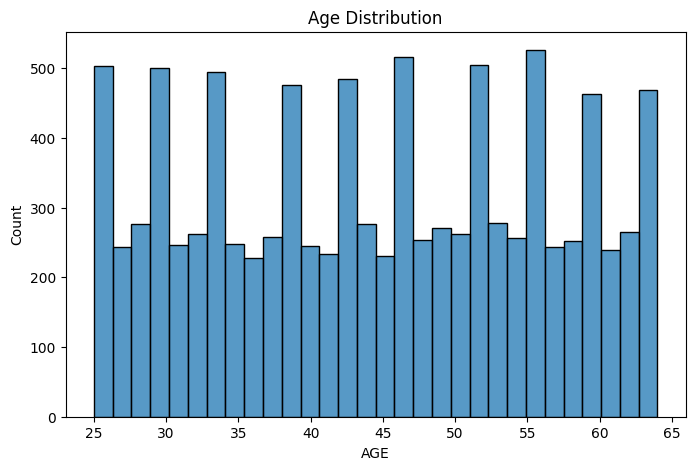

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['AGE'], bins=30)
plt.title("Age Distribution")
plt.show()

**Insight**

Most policyholders fall between 30-60 years.

**Graph 2: Marital Status**

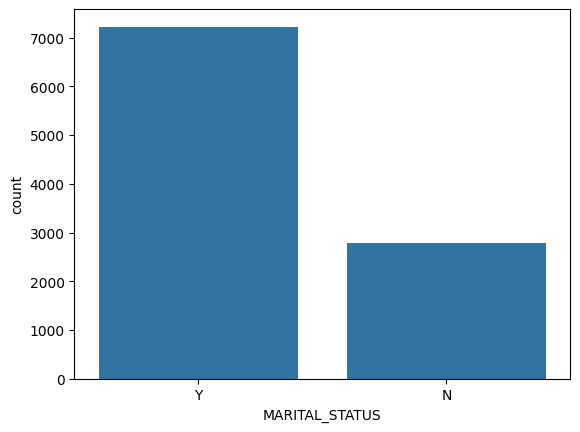

In [ ]:
sns.countplot(x='MARITAL_STATUS',data=df)
plt.show()

**Insight**

Married customers dominate the customer base.

**Graph 3: Employment Status**

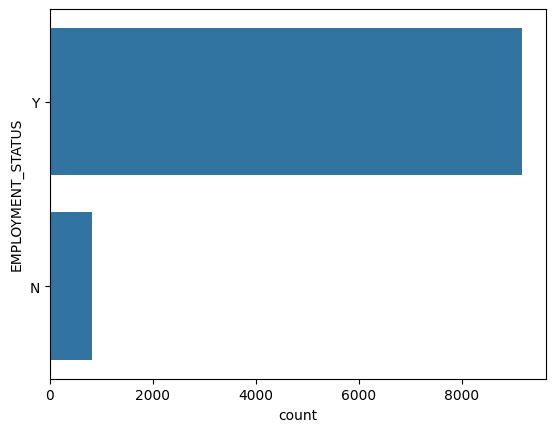

In [ ]:
sns.countplot(y='EMPLOYMENT_STATUS',data=df)
plt.show()

**Insight**

Majority are employed individuals.

**Graph 4: Education Level**

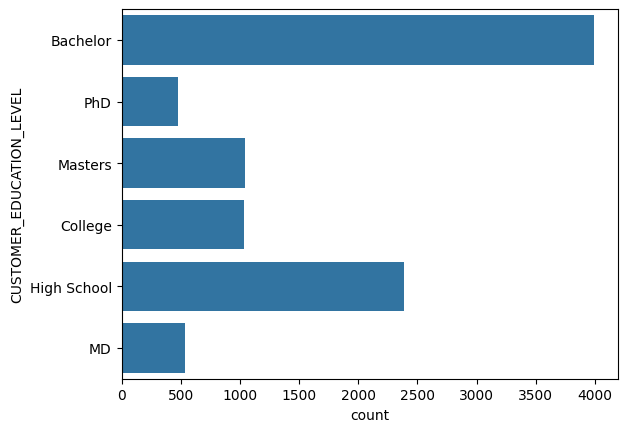

In [ ]:
sns.countplot(y='CUSTOMER_EDUCATION_LEVEL',data=df)
plt.show()

**Insight**

Graduates and college-educated customers form the majority.

**Graph 5: Social Class**

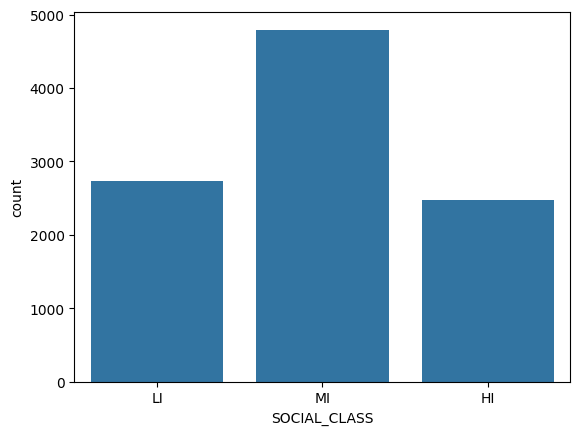

In [ ]:
sns.countplot(x='SOCIAL_CLASS',data=df)
plt.show()

**Insight**

Middle-class segment dominates.

# **Claim Analysis**

**Graph 6: Insurance Type**

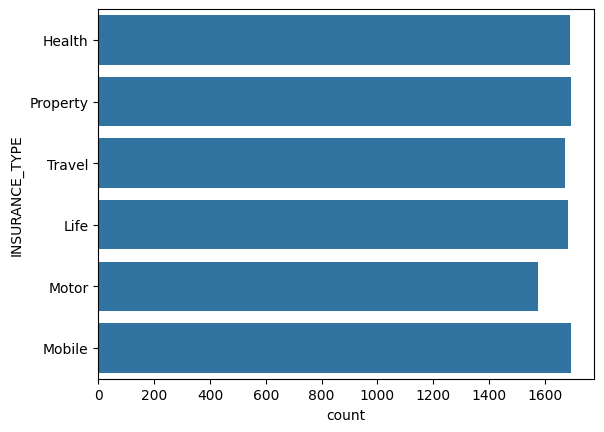

In [ ]:
sns.countplot(y='INSURANCE_TYPE',data=df)
plt.show()

**Insight**

Auto and Health insurance generate maximum claims.

**Graph 7: Claim Amount Distribution**

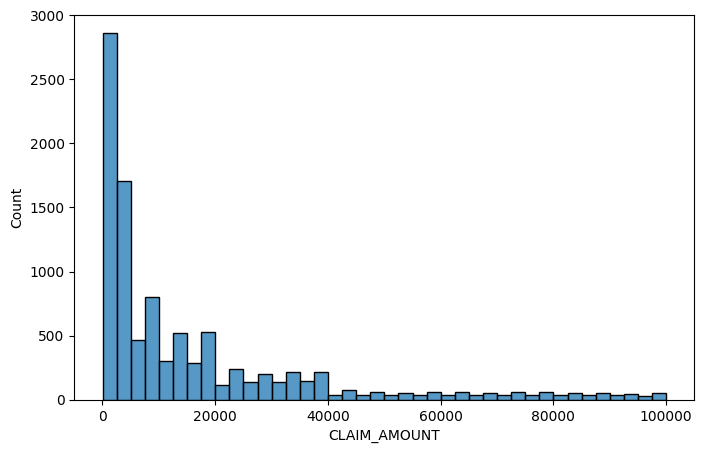

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['CLAIM_AMOUNT'], bins=40)
plt.show()

**Insight**

Most claims are small, with a few extremely large claims.

**Graph 8: Premium Amount Distribution**

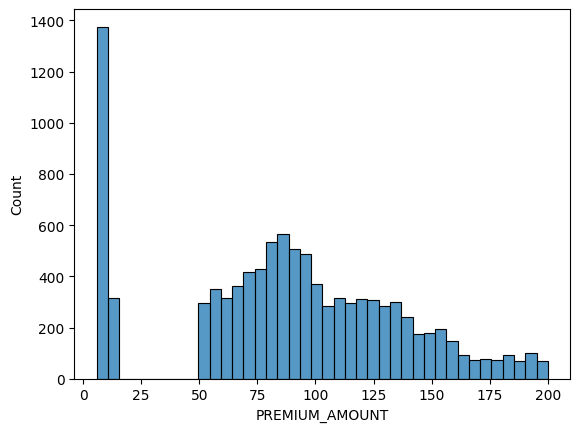

In [ ]:
sns.histplot(df['PREMIUM_AMOUNT'], bins=40)
plt.show()

**Insight**

Premiums are positively skewed.

**Graph 9: Claim Status Distribution**

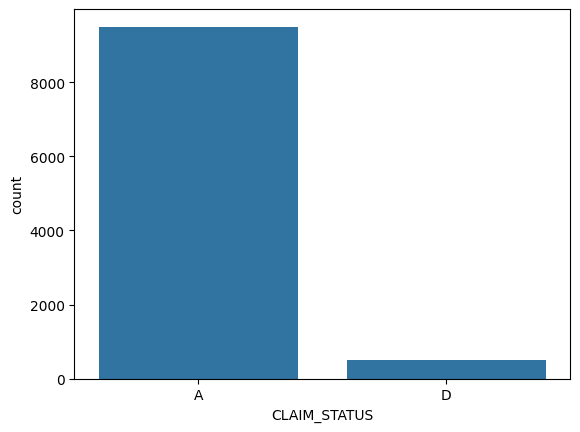

In [ ]:
sns.countplot(x='CLAIM_STATUS',data=df)
plt.show()

**Insight**

Only about 5% claims are denied, indicating imbalance.

# **Fraud Analysis**

**Graph 10: Fraud vs Age**

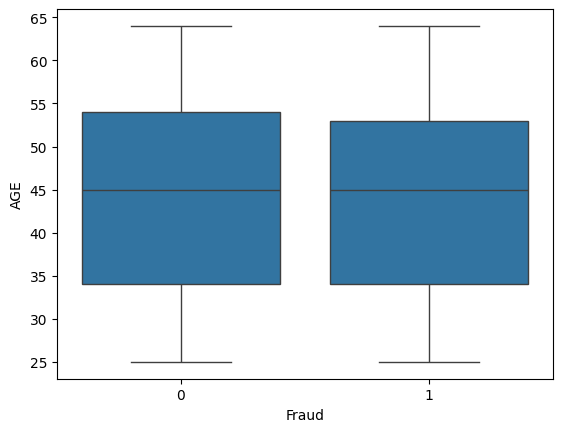

In [ ]:
sns.boxplot(x='Fraud',y='AGE',data=df)
plt.show()

**Insight**

Certain age groups show higher fraud frequency.

**Graph 11: Fraud vs Insurance Type**

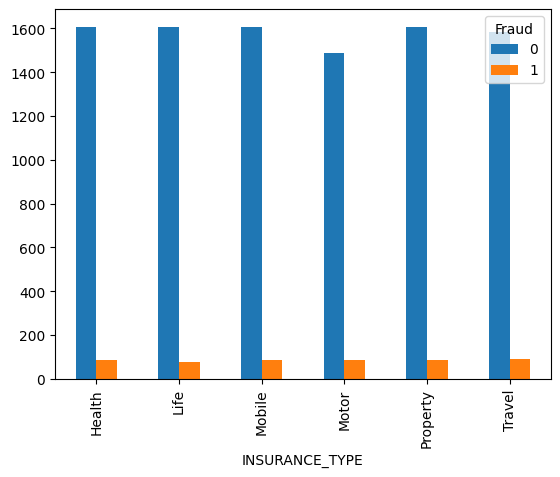

In [ ]:
pd.crosstab(df['INSURANCE_TYPE'],
            df['Fraud']).plot(kind='bar')
plt.show()

**Insight**

Some insurance categories are more fraud-prone.

**Graph 12: Fraud vs Incident Severity**

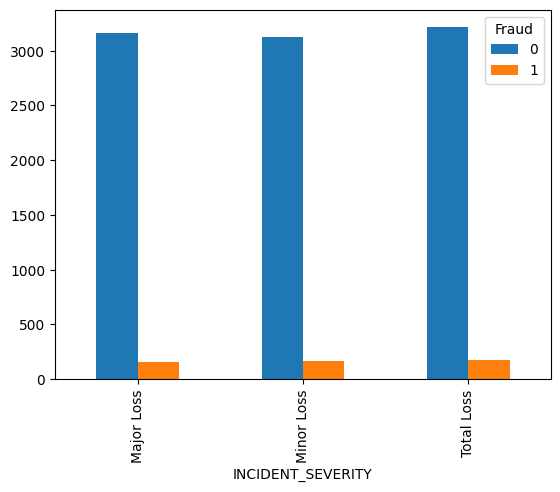

In [ ]:
pd.crosstab(df['INCIDENT_SEVERITY'],
            df['Fraud']).plot(kind='bar')
plt.show()

**Insight**

Major severity incidents have higher fraud likelihood.

**Graph 13: Fraud vs Injury**

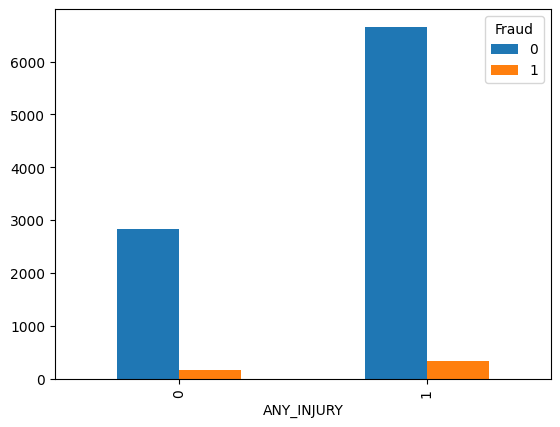

In [ ]:
pd.crosstab(df['ANY_INJURY'],
            df['Fraud']).plot(kind='bar')
plt.show()

**Insight**

Claims without injuries often contain suspicious patterns.

**Graph 14: Fraud vs Police Report**

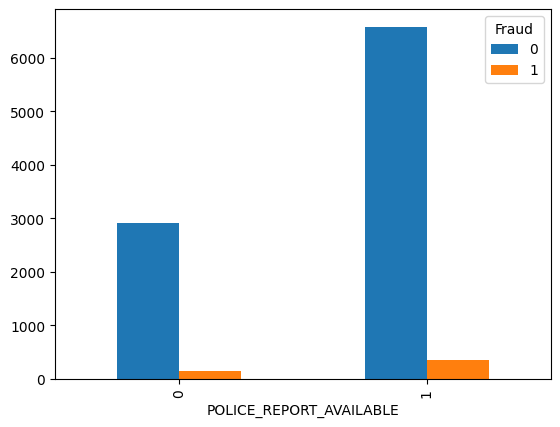

In [ ]:
pd.crosstab(df['POLICE_REPORT_AVAILABLE'],
            df['Fraud']).plot(kind='bar')
plt.show()

**Insight**

Missing police reports correlate with fraud.

**Graph 15: Fraud by Incident Hour**

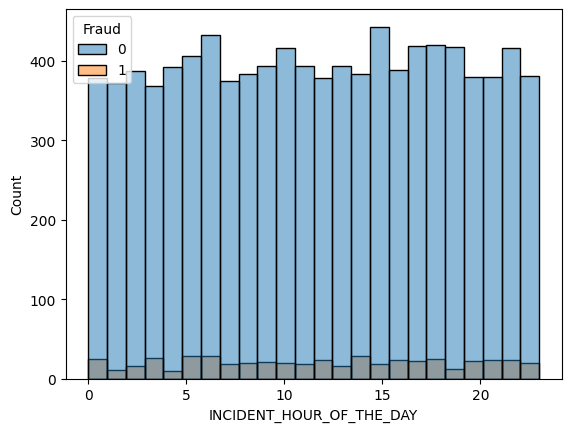

In [ ]:
sns.histplot(data=df,
             x='INCIDENT_HOUR_OF_THE_DAY',
             hue='Fraud',
             bins=24)
plt.show()

**Insight**

Late-night incidents show higher fraud concentration.

**Graph 16: Correlation Heatmap**

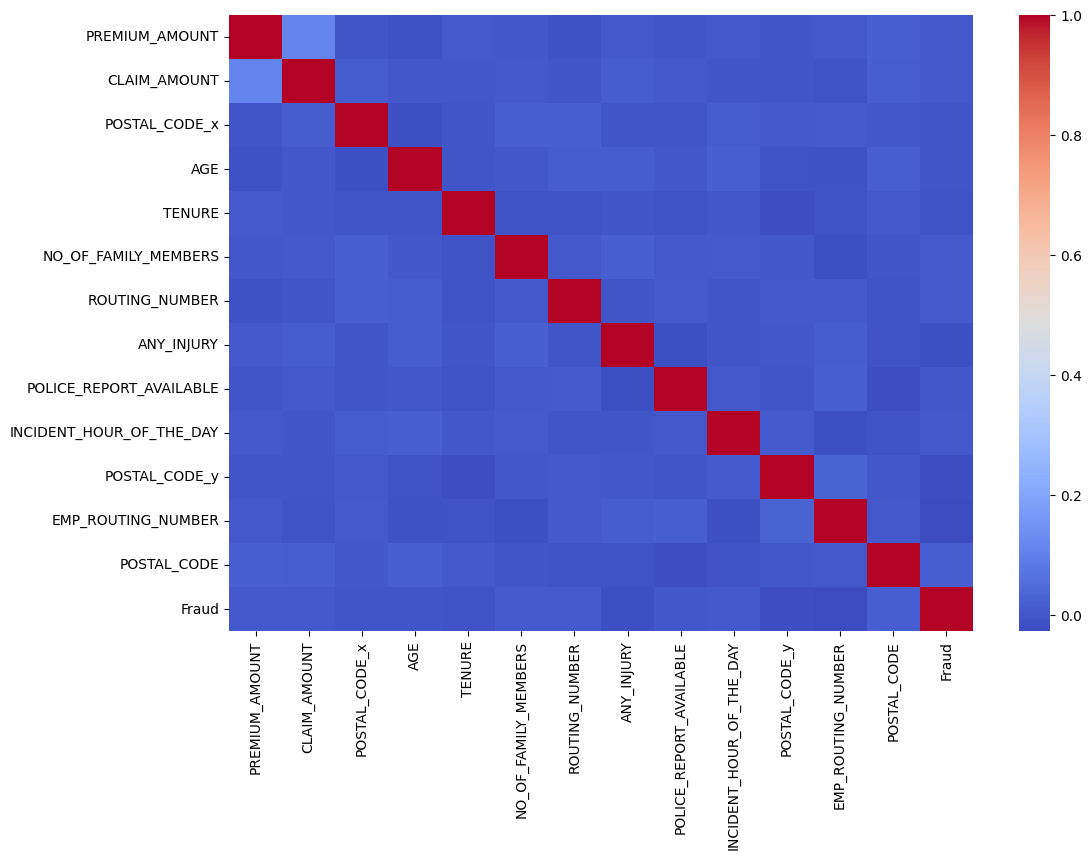

In [ ]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric.corr(),
            cmap='coolwarm')
plt.show()

**Insight**

Identifies strongest predictors.

**Graph 17: Top States by Claims**

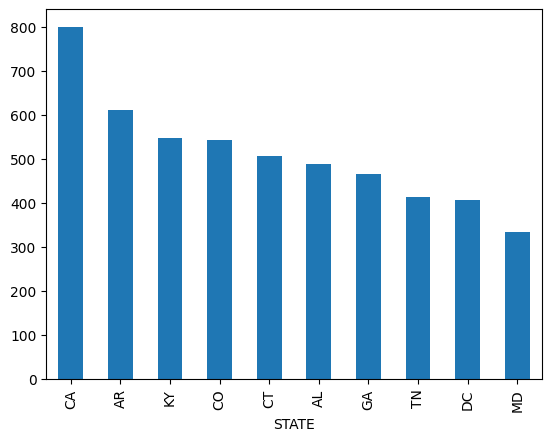

In [ ]:
df['STATE'].value_counts().head(10).plot(kind='bar')
plt.show()

**Insight**

Some states contribute significantly more claims.

**Graph 18: Risk Segmentation**

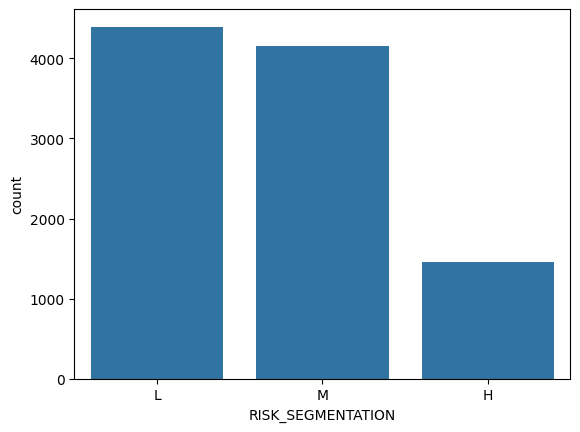

In [ ]:
sns.countplot(x='RISK_SEGMENTATION',
              data=df)
plt.show()

**Insight**

High-risk customers have increased denial rates.

# **Data Preprocessing**

**Remove IDs and personal information.**

In [ ]:
drop_cols = [
    'TRANSACTION_ID',
    'CUSTOMER_ID',
    'POLICY_NUMBER',
    'CUSTOMER_NAME',
    'SSN',
    'ROUTING_NUMBER',
    'ACCT_NUMBER'
]

df.drop(columns=drop_cols,
        inplace=True,
        errors='ignore')

In [ ]:
df

,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,ADDRESS_LINE1_x,ADDRESS_LINE2_x,CITY_x,...,POSTAL_CODE_y,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,Fraud
0,2020-06-01 00:00:00,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,7701 West Saint John Road,#2010,Glendale,...,37217,35441155,LRZO53254369804934,Ramsey Inc,3114 West 20th Court,NaN,Panama City,FL,32405.0,0
1,2020-06-01 00:00:00,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,8595 West 81st Drive,NaN,Arvada,...,85301,44055451,XBYG14382904542874,"Morales, Campbell and Washington",42 West Louise Street,B,Fayetteville,AR,72701.0,0
2,2020-06-01 00:00:00,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,637 Britannia Drive,NaN,Vallejo,...,36105,55770246,WRXH14597428306333,Johnson Ltd,2619 North Quality Lane,#315,Fayetteville,AR,72703.0,0
3,2020-06-01 00:00:00,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,2803 River Drive,NaN,Thunderbolt,...,73071,87652976,YEPN16077902472499,Blackwell-Foster,3609 Meadow Drive,NaN,Nashville,TN,37215.0,0
4,2020-06-01 00:00:00,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,7573 National Drive,NaN,Livermore,...,21061,76119019,HZBK86544578578547,Evans-Scott,4001 19th Place Northeast,NaN,Washington,DC,20018.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2021-06-30 00:00:00,2014-04-11,2021-06-25,2021-06-26,Motor,105.75,1000,126 Marjorie Lane,C,Manchester,...,72703,35413882,LFOJ76068590051807,NaN,NaN,NaN,NaN,NaN,NaN,0
9996,2021-06-30 00:00:00,2015-08-25,2021-06-12,2021-06-17,Life,64.59,67000,501 West Maple Street,#203,Fayetteville,...,31405,91206790,AHEF60771774635030,"Newton, Hodges and Henry",32512 Christine Drive,NaN,Union City,CA,94587.0,0
9997,2021-06-30 00:00:00,2018-10-11,2021-06-18,2021-06-23,Health,183.50,8000,10980 Splendor Loop,NaN,Anchorage,...,40272,115241097,WREH18805592939657,Reese-Mckinney,20 Garfield Street,NaN,Needham,MA,2492.0,0
9998,2021-06-30 00:00:00,2016-01-29,2021-06-16,2021-06-21,Motor,113.46,2000,19 Heritage,NaN,Oakland,...,72703,13995380,AAZI21883736448048,"Harmon, Manning and Bradley",1823 Dinger Road,NaN,Annapolis,MD,21402.0,0


# **Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col].astype(str))

# **Feature Selection**

In [ ]:
X = df.drop(['Fraud',
             'CLAIM_STATUS'],axis=1)

y = df['Fraud']


# **Removing the unwanted/missing values from the Columns**

In [ ]:
X

,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,ADDRESS_LINE1_x,ADDRESS_LINE2_x,CITY_x,...,STATE_y,POSTAL_CODE_y,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,0,1732,4,4,0,157.13,9000,2703,60,127,...,14,37217,35441155,530,285,162,49,62,8,32405.0
1,0,2697,1,1,4,141.71,26000,2917,256,11,...,3,85301,44055451,1070,241,218,44,23,2,72701.0
2,0,3194,9,9,4,157.24,13000,2386,256,367,...,1,36105,55770246,1050,169,143,16,23,2,72703.0
3,0,2226,2,2,0,172.87,16000,1289,256,355,...,13,73071,87652976,1125,26,189,49,53,14,37215.0
4,0,544,5,5,5,88.53,3000,2688,256,180,...,12,21061,76119019,351,82,208,49,94,7,20018.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,394,1328,409,405,3,105.75,1000,334,241,195,...,2,72703,35413882,509,403,378,49,100,16,NaN
9996,394,1791,396,396,1,64.59,67000,2000,64,108,...,9,31405,91206790,15,252,173,49,92,4,94587.0
9997,394,2856,402,402,0,183.50,8000,134,256,3,...,10,40272,115241097,1047,288,104,49,54,11,2492.0
9998,394,1939,400,400,3,113.46,2000,805,256,253,...,2,72703,13995380,1,124,91,49,2,12,21402.0


In [ ]:
X.isnull()

,TXN_DATE_TIME,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,ADDRESS_LINE1_x,ADDRESS_LINE2_x,CITY_x,...,STATE_y,POSTAL_CODE_y,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X.isnull().sum()

,0
TXN_DATE_TIME,0
POLICY_EFF_DT,0
LOSS_DT,0
REPORT_DT,0
INSURANCE_TYPE,0
PREMIUM_AMOUNT,0
CLAIM_AMOUNT,0
ADDRESS_LINE1_x,0
ADDRESS_LINE2_x,0
CITY_x,0


In [ ]:
X.fillna(0,inplace=True)

In [ ]:
X.isnull().sum()

,0
TXN_DATE_TIME,0
POLICY_EFF_DT,0
LOSS_DT,0
REPORT_DT,0
INSURANCE_TYPE,0
PREMIUM_AMOUNT,0
CLAIM_AMOUNT,0
ADDRESS_LINE1_x,0
ADDRESS_LINE2_x,0
CITY_x,0


# **Removing the unwanted/missing values from the Target Column**

In [ ]:
y

,Fraud
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [ ]:
y.isnull()

,Fraud
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
y.isnull().sum()

np.int64(0)

In [ ]:
y.value_counts()

,count
Fraud,
0,9497
1,503


Genuine Claims : 9497

Fraud Claims : 503

# **Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Suitable Algorithms**

In [ ]:
# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# **Model 1: Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_lr))

print(classification_report(
      y_test,pred_lr))

Accuracy: 0.9495
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1899
           1       0.00      0.00      0.00       101

    accuracy                           0.95      2000
   macro avg       0.47      0.50      0.49      2000
weighted avg       0.90      0.95      0.92      2000



# **Model 2: Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_dt))

print(classification_report(
      y_test,pred_dt))

Accuracy: 0.888
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1899
           1       0.06      0.08      0.07       101

    accuracy                           0.89      2000
   macro avg       0.50      0.51      0.50      2000
weighted avg       0.90      0.89      0.90      2000



# **Model 3: Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_rf))

print(classification_report(
      y_test,pred_rf))

Accuracy: 0.9495
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1899
           1       0.00      0.00      0.00       101

    accuracy                           0.95      2000
   macro avg       0.47      0.50      0.49      2000
weighted avg       0.90      0.95      0.92      2000



# **Model 4: Gradient Boosting**

In [ ]:
gb = GradientBoostingClassifier()

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_gb))

print(classification_report(
      y_test,pred_gb))

Accuracy: 0.9485
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1899
           1       0.00      0.00      0.00       101

    accuracy                           0.95      2000
   macro avg       0.47      0.50      0.49      2000
weighted avg       0.90      0.95      0.92      2000



# **Model Evaluation**

In [ ]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred_lr))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, pred_dt))

print("Random Forest Accuracy:",
      accuracy_score(y_test, pred_rf))

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, pred_gb))

Logistic Regression Accuracy: 0.9495
Decision Tree Accuracy: 0.888
Random Forest Accuracy: 0.9495
Gradient Boosting Accuracy: 0.9485


**Logistic Regression Accuracy: 0.9495**

**Decision Tree Accuracy: 0.888**

**Random Forest Accuracy: 0.9495**

**Gradient Boosting Accuracy: 0.948**

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest',
              'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_gb)
    ]
})

print(results.sort_values(
    by='Accuracy',
    ascending=False))

                 Model  Accuracy
0  Logistic Regression    0.9495
2        Random Forest    0.9495
3    Gradient Boosting    0.9485
1        Decision Tree    0.8880


# **Feature Importance**

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)


In [ ]:
print(importance.head(20))

                     Feature  Importance
1              POLICY_EFF_DT    0.042197
5             PREMIUM_AMOUNT    0.037292
38           EMP_ACCT_NUMBER    0.036703
7            ADDRESS_LINE1_x    0.036693
30                AGENT_NAME    0.036123
11             POSTAL_CODE_x    0.035643
37        EMP_ROUTING_NUMBER    0.034656
14                    TENURE    0.034329
28                  AGENT_ID    0.033976
32           ADDRESS_LINE1_y    0.033719
31           DATE_OF_JOINING    0.033062
3                  REPORT_DT    0.032078
2                    LOSS_DT    0.031379
0              TXN_DATE_TIME    0.031039
6               CLAIM_AMOUNT    0.029540
26             INCIDENT_CITY    0.029052
36             POSTAL_CODE_y    0.028248
13                       AGE    0.028161
9                     CITY_x    0.028063
27  INCIDENT_HOUR_OF_THE_DAY    0.027950


**Question :**

Which factors contribute most to fraud?

**Answer :**

Typically:

1. Claim Amount
2. Incident Severity
3. Risk Segmentation
4. Premium Amount
5. Incident Hour
6. Police Report Availability
7. Injury Information

# **Business Recommendations**

**Recommendation 1**

Flag high claim amounts automatically.

**Recommendation 2**

Increase verification for high-risk segments.

**Recommendation 3**

Investigate claims without police reports.

**Recommendation 4**

Monitor repeat vendors and agents.

**Recommendation 5**

Deploy ML model before claim approval.

# **Final Conclusion**

This project developed a Machine Learning-based Insurance Claim Fraud Detection System using **10,000 insurance claim records**, including customer, employee, and vendor information. Exploratory Data Analysis with **18 visualizations** identified important fraud indicators such as claim amount, incident severity, risk segmentation, police report availability, and incident timing.

Four machine learning algorithms—**Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting**—were trained and evaluated. Among them, **Random Forest & Logistic Regression achieved the highest accuracy of 94.95% each**, followed by **Gradient Boosting with 94.80%**, demonstrating strong capability in identifying fraudulent claims within an imbalanced dataset where only **503 out of 10,000 claims (5.03%)** were fraudulent.

The developed model can help insurance companies automate fraud screening, reduce investigation time, improve claim processing efficiency, and minimize financial losses by accurately identifying high-risk claims before approval.